```
<07_apple_banana.ipynb>

제미나이 의존도: 70-80%

YOLOv8 아키텍처 커스텀 및 경량화해서 아키텍처 파일(my_diet_yolo.yam) 구축을 했다.
YOLOv8 Backbone (특징 추출기) 레이어 압축..
해상도가 높지 않은 과일 이미지 특성을 고려해서 레이어를 커스텀해서 연산 속도 최적화를 시도했다.
합성곱 레이어의 깊이 배율과 채널 배율을 제어하는 depth_multiple과 width_multiple 인자를 하향 조정했다.
연산 속도는 빨라졌지만, 정확도는 0.01을 찍을 정도로 너무 형편없었다.
다음엔 아키텍처 커스텀을 제대로 해서 연산도 빠르고 정확도도 오리지널 모델 못지 않게 잘 나와주는 커스텀을 해보고 싶다.
```

In [2]:
import os

dataset_path = "dataset/apple_banana"

train_image_path = os.path.join(dataset_path, "train/images")
train_label_path = os.path.join(dataset_path, "train/labels")

# 8:1:1 비율로 train 데이터셋을 train / val / test로 쪼갤 예정
print(len(os.listdir(train_image_path)))

207


In [3]:
# val / test 디렉토리 생성
val_image_path = os.path.join(dataset_path, "valid/images")
val_label_path = os.path.join(dataset_path, "valid/labels")

test_image_path = os.path.join(dataset_path, "test/images")
test_label_path = os.path.join(dataset_path, "test/labels")

paths = []
paths.append(val_image_path)
paths.append(val_label_path)
paths.append(test_image_path)
paths.append(test_label_path)

for path in paths:
    os.makedirs(path, exist_ok=True)

In [9]:
from pathlib import Path
import random
import shutil

train_images = os.listdir(train_image_path)
train_txts = os.listdir(train_label_path)

random.seed(42)
random.shuffle(train_images)

split_idx = int(len(train_images) * 0.8)
train_data = train_images[:split_idx]
val_test_data = train_images[split_idx:]

split_idx_for_val_test = int(len(val_test_data) * 0.5)
val_data = val_test_data[:split_idx_for_val_test]
test_data = val_test_data[split_idx_for_val_test:]

print(len(train_data), len(val_data), len(test_data)) # 165 21 21

165 21 21


In [11]:
def move_train_image_label_to_val_test(data, dest_image_path, dest_label_path):
    count = 0
    for image in data: # image: 123apple.jpg
        pure_name = Path(image).stem # 123apple
        txt_file = f"{pure_name}.txt"
        if txt_file in train_txts:
            full_image_path = os.path.join(train_image_path, image)
            full_txt_path = os.path.join(train_label_path, txt_file)
            shutil.move(full_image_path, dest_image_path)
            shutil.move(full_txt_path, dest_label_path)
            count += 1

    print(f"{count}개 이동 완료")

In [12]:
move_train_image_label_to_val_test(val_data, val_image_path, val_label_path)
move_train_image_label_to_val_test(test_data, test_image_path, test_label_path)

21개 이동 완료
21개 이동 완료


In [14]:
from ultralytics import YOLO
import os
import time

current_dir = os.getcwd()

model_org = YOLO("yolov8n.pt")

start_time = time.time()

model_org.train(
    data="dataset/apple_banana/data.yaml", epochs=30, imgsz=640, device="mps", 
    save=True, project=os.path.join(current_dir, "runs"), name="apple_banana_org"
)

elapsed_time = int(time.time() - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"[org 모델 소요시간] {mins}min {secs}sec")


start_time = time.time()

model_diet = YOLO("dataset/apple_banana/my_diet_yolo.yaml", task='detect')
model_diet.train(
    data="dataset/apple_banana/data.yaml", epochs=30, imgsz=640, device="mps", 
    save=True, project=os.path.join(current_dir, "runs"), name="apple_banana_diet"
)
elapsed_time = int(time.time() - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"[diet 모델 소요시간] {mins}min {secs}sec")



New https://pypi.org/project/ultralytics/8.4.93 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/apple_banana/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=apple_banana_or

In [20]:
org_model = YOLO("runs/apple_banana_org/weights/best.pt")
diet_model = YOLO("runs/apple_banana_diet/weights/best.pt")

test_img = "dataset/apple_banana/test/images/12_webp.rf.Fi26I1AyUqPQRYFVdebO.webp"

org_times = []
for _ in range(10):
    start = time.time()
    org_model.predict(source=test_img, device="mps", verbose=False) # 로그 지우기 위해 verbose=False
    org_times.append(time.time() - start)

avg_org_time = sum(org_times) / 10
print(f"[순정 YOLOv8n] 10회 평균 추론 시간: {avg_org_time * 1000:.2f} ms")

[순정 YOLOv8n] 10회 평균 추론 시간: 25.69 ms


In [21]:
diet_times = []
for _ in range(10):
    start = time.time()
    diet_model.predict(source=test_img, device="mps", verbose=False)
    diet_times.append(time.time() - start)

avg_diet_time = sum(diet_times) / 10
print(f"[경량 YOLOv8n] 10회 평균 추론 시간: {avg_diet_time * 1000:.2f} ms")

[경량 YOLOv8n] 10회 평균 추론 시간: 14.71 ms


In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

def inspect_detection(model, image_path, conf_threshold=0.25, iou_threshold=0.45):
    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device="mps"
    )

    annotated_img = preds[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img_rgb)
    plt.title(f"Conf: {conf_threshold} | IoU: {iou_threshold}", fontsize=14)
    plt.axis('off')
    plt.show()

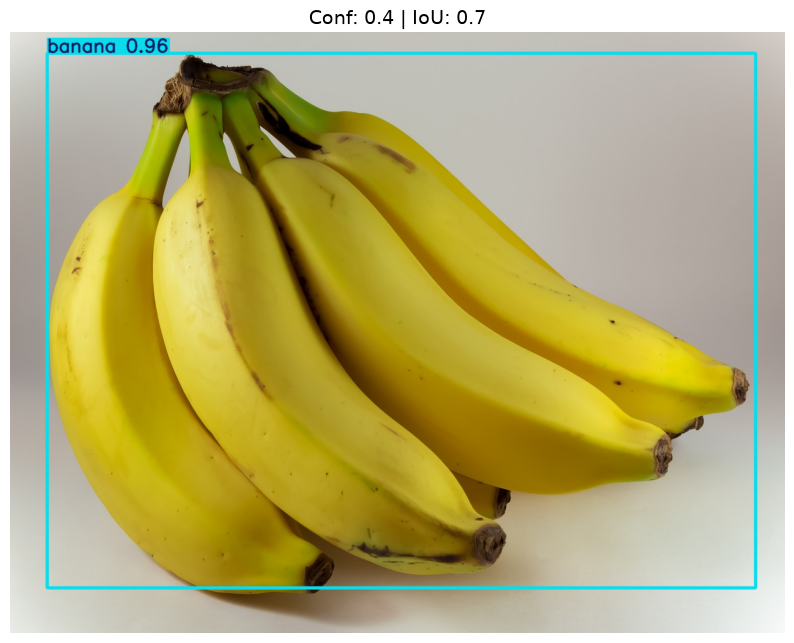

In [25]:
image_path = "dataset/apple_banana/test/images/banana-1025109_1280_jpg.rf.4R9BQARflgcT1GC8gYLj.jpg"
inspect_detection(org_model, image_path, 0.4, 0.7)